# SPINN 扩散项 `Var` 能否准确反映 OU 过程 $\sigma^2$ 的变化？

**目标**：在设计新的输出头 / 自监督损失（直接估计 $\sigma^2/\theta$ 与 $\sigma^2$）之前，先评估**现有 SPINN 默认流程**输出的扩散项 `VarX / VarY`（即 `s1`）能否在**单条轨迹、单帧尺度**上准确跟踪 OU 过程 $\sigma_t^2$ 的变化。

OU 过程 $\mathrm{d}X_t=\theta_t(\mu-X_t)\,\mathrm{d}t+\sigma_t\,\mathrm{d}W_t$ 在一帧 $\Delta$ 内的精确转移为

$$
X_{n+1}\mid X_n\sim\mathcal N\!\Big(\mu+(X_n-\mu)e^{-\theta_n\Delta},\;\underbrace{\sigma_n^2\,\tfrac{1-e^{-2\theta_n\Delta}}{2\theta_n}}_{V_n\;(\text{单步条件方差})}\Big).
$$

SPINN 的扩散网络拟合的是一步预测残差平方 $u_n=(x_{n+1}-y^{(1)}_n)^2$，所以 `Var` 的**理论目标**是 $V_n$，而不是 $\sigma_n^2$ 本身：

$$
\frac{V_n}{\Delta}=\sigma_n^2\cdot\underbrace{\frac{1-e^{-2\theta_n\Delta}}{2\theta_n\Delta}}_{g(\theta_n\Delta)\;\le 1}.
$$

因此要回答的问题拆成两层：

| 层次 | 问题 | 本 notebook 的检验 |
|---|---|---|
| **(a) 网络层** | `Var` 是否准确估计了 $V_n$？偏差多大？逐帧噪声多大？能多快跟上变化？ | §4 结构检查、§6.1–6.4、§6.6 |
| **(b) 物理层** | 由 $V_n$ 读 $\sigma_n^2$ 需要除以 $g(\theta\Delta)$，它依赖 $\theta$ —— $\theta$ 变化会不会被误读成 $\sigma^2$ 变化？ | §6.5 |

所有测试都在**独立生成、每条轨迹平衡位置 $\mu_i$ 不同**的轨迹上进行，并且**每条轨迹单独归一化**（相当于每条轨迹是一个单独的 csv 文件），即严格的单轨迹场景。

## 0. 环境与配置

与 `SPINN_OU_demo.ipynb` 相同：直接调用仓库的 `train` / `train_sigma` / `transform`，不修改仓库代码；`QUICK=True` 配置，训练数据与 demo 完全相同（6 种 $\theta_t,\sigma_t$ 组合，`SEED=0`）。这里只需要主网络和扩散网络，所以跳过漂移网络。

In [1]:
import os, sys, time, types, shutil, argparse, warnings
warnings.filterwarnings('ignore')

REPO_ROOT = os.path.abspath('.')
while not os.path.exists(os.path.join(REPO_ROOT, 'TrainJumpSDEsTransform.py')):
    parent = os.path.dirname(REPO_ROOT)
    if parent == REPO_ROOT:
        raise FileNotFoundError('请把 notebook 放在 SPINN 仓库内运行')
    REPO_ROOT = parent
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

try:
    import pkg_resources  # noqa: F401
except ImportError:  # 新版 setuptools 已移除 pkg_resources，仓库的 robust_loss_pytorch 需要它
    _shim = types.ModuleType('pkg_resources')
    def _resource_stream(package, resource):
        base = os.path.dirname(sys.modules[package].__file__)
        return open(os.path.join(base, resource), 'rb')
    _shim.resource_stream = _resource_stream
    sys.modules['pkg_resources'] = _shim

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import ConcatDataset

from TrainJumpSDEsTransform import (DatasetTracks, generate_dataset_torch, train, train_sigma,
                                    transform, generate_sigma_sets_torch)
from utils.csv2npy import v_normalize_batch_encoder

torch.set_num_threads(os.cpu_count())
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('torch:', torch.__version__, '| device:', DEVICE, '| threads:', torch.get_num_threads())

# 配色（已用 dataviz 校验器检查色盲可分性）
C_TRUE, C_SPINN, C_RV, C_BLK, C_RV2 = '#3a3a38', '#2a78d6', '#eb6834', '#1f9e89', '#8a5cc2'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 1.6,
                     'font.size': 9, 'legend.frameon': False, 'axes.unicode_minus': False})

torch: 2.14.0+cu130 | device: cpu | threads: 4


In [2]:
SEED = 0
cfg = argparse.Namespace(
    epochs=12, epochs_VDt=6, batch_size=20, lr=1e-3, seed=SEED, clip_grad=5.0,
    scale=0.375, warmup_steps=2000, RESUME=False,
    default_enc_nn=((64, 'gelu'), (64, 'gelu')), hidden_size=64, layers=2, h_dim=32,
    d_model=64, n_heads=4, enc_layers=2, dropout=0.25, is_var_head=True,
    in_dim=2, out_dim=2, pred_length=50, encoder_length=50,
    beta_ac=0.5, beta_weight=0.5, beta_observe=0.0, beta_conti=0.0,
    noise_adding=0.0, sample_rates=1.0, sample_nums=0,
    dload='./model_dir/ou_var_eval', save_name='ou-var', model_name='ou-var.pth',
    device=DEVICE,
)
shutil.rmtree(cfg.dload, ignore_errors=True)
os.makedirs(cfg.dload, exist_ok=True)
np.random.seed(SEED); torch.manual_seed(SEED)
L_ENC, L_PRED = cfg.encoder_length, cfg.pred_length
WIN = L_ENC + L_PRED
DT, T_LEN = 0.02, 1000
t_grid = np.arange(T_LEN) * DT
T_END = t_grid[-1] + DT

## 1. 数据：精确离散化的时变 OU

`simulate_ou` 支持每条轨迹不同的平衡位置 $\mu_i$。训练集与 demo 一致（$\mu=(2,-1)$，每个情景 12 条）。

In [3]:
def square_wave(t, period):
    return (np.floor(t / (period / 2)) % 2).astype(float)

def simulate_ou(theta_fn, sigma_fn, n_tracks, rng, mu_sd=0.0, mu0=(2.0, -1.0)):
    th, sg = theta_fn(t_grid), sigma_fn(t_grid)
    a = np.exp(-th * DT)
    sd = sg * np.sqrt((1 - a ** 2) / (2 * th))                  # 单步条件标准差 √V_n
    mu = np.asarray(mu0) + mu_sd * rng.standard_normal((n_tracks, 2))
    X = np.empty((n_tracks, T_LEN, 2))
    X[:, 0] = mu + sg[0] / np.sqrt(2 * th[0]) * rng.standard_normal((n_tracks, 2))
    for n in range(T_LEN - 1):
        X[:, n + 1] = mu + (X[:, n] - mu) * a[n] + sd[n] * rng.standard_normal((n_tracks, 2))
    return dict(X=X, theta=th, sigma=sg, V=sd ** 2, sig2=sg ** 2)

TRAIN_SC = {
    'A': (lambda t: 4.0 + 0 * t, lambda t: 1.0 + 0 * t),
    'B': (lambda t: 4.0 + 0 * t, lambda t: np.where(t < T_END / 2, 0.6, 1.5)),
    'C': (lambda t: 4.0 + 0 * t, lambda t: 1.0 + 0.5 * np.sin(2 * np.pi * t / 10)),
    'D': (lambda t: 1.0 + 9.0 * t / T_END, lambda t: 1.0 + 0 * t),
    'E': (lambda t: 5.0 + 3.0 * np.sin(2 * np.pi * t / 8), lambda t: 0.5 + 1.0 * t / T_END),
    'F': (lambda t: 2.0 + 6.0 * square_wave(t, 10), lambda t: 1.4 - 0.7 * square_wave(t, 10)),
}
rng = np.random.default_rng(SEED)
TRAIN = {}
for k, (thf, sgf) in TRAIN_SC.items():
    TRAIN[k] = simulate_ou(thf, sgf, 12, rng)
    simulate_ou(thf, sgf, 16, rng)      # 与 demo 保持相同的随机数消耗（demo 在此生成测试集）
print('训练集：', {k: v['X'].shape for k, v in TRAIN.items()})

训练集： {'A': (12, 1000, 2), 'B': (12, 1000, 2), 'C': (12, 1000, 2), 'D': (12, 1000, 2), 'E': (12, 1000, 2), 'F': (12, 1000, 2)}


## 2. 切片与归一化

- 切片方式与 `utils/csv2npy.py` 相同：regular 片段与 head 片段的**预测段**交替覆盖轨迹，每块 50 帧（第 $b$ 块 = 帧 $[50b,\,50b+50)$）。
- 训练时每个“文件”（情景）整体归一化，与 demo 一致；
- **测试时每条轨迹单独归一化**（`v_normalize_batch_encoder` 对单条轨迹的片段调用），对应“单条轨迹 = 一个文件”。

In [4]:
def segment(arr, is_head=False):
    if is_head:
        pad = np.repeat(arr[:, :1], L_PRED, axis=1)
        arr = np.concatenate([pad, arr[:, :-L_PRED]], axis=1)
    starts = np.arange(0, arr.shape[1] - WIN + 1, WIN)
    return np.concatenate([arr[:, s:s + WIN][:, None] for s in starts], axis=1)   # (N, nW, WIN, ...)

def build_segments(X, per_track=True):
    N = X.shape[0]
    frame = np.broadcast_to(np.arange(T_LEN), (N, T_LEN))
    track = np.broadcast_to(np.arange(N)[:, None], (N, T_LEN))
    out = {}
    for kind, head in [('regular', False), ('head', True)]:
        seg = segment(X, head)
        nW = seg.shape[1]
        if per_track:
            xs, ns = [], []
            for i in range(N):
                xn, s = v_normalize_batch_encoder(seg[i], encoder_len=L_ENC)
                xs.append(xn); ns.append(np.broadcast_to(s, (nW, 2)))
            xn, norm = np.concatenate(xs), np.concatenate(ns)
        else:
            xn, s = v_normalize_batch_encoder(seg.reshape(-1, WIN, 2), encoder_len=L_ENC)
            norm = np.broadcast_to(s, (N * nW, 2))
        out[kind] = dict(x=xn.astype(np.float32), norm=np.asarray(norm),
                         frame=segment(frame, head).reshape(-1, WIN),
                         track=segment(track, head).reshape(-1, WIN))
    return out

TRAIN_SEGS = {k: build_segments(v['X'], per_track=False) for k, v in TRAIN.items()}

## 3. 训练主网络 + 扩散网络（仓库默认流程）

In [5]:
train_parts = [DatasetTracks(TRAIN_SEGS[k][kind]['x'], cfg) for k in TRAIN for kind in ['regular', 'head']]
train_ds, val_ds = generate_dataset_torch(ConcatDataset(train_parts), train_prob=0.9, seed=SEED)
steps_per_epoch = int(np.ceil(len(train_ds) / cfg.batch_size))
cfg.warmup_steps = max(100, int(0.3 * steps_per_epoch * cfg.epochs))
t0 = time.time()
model = train(train_datasets=train_ds, config=cfg, test_datasets=val_ds)
t1 = time.time()
cfg.epochs = cfg.epochs_VDt
cfg.beta_ac, cfg.beta_weight = 0.5, 0.5
cfg.warmup_steps = max(100, int(0.3 * steps_per_epoch * cfg.epochs))
train_sigma(train_ds, model, cfg, is_train=True)
print(f'耗时：主网络 {t1 - t0:.0f}s | 扩散网络 {time.time() - t1:.0f}s')

2026-09-25 07:47:39,825 	 [INFO | TrainJumpSDEsTransform.py:586] > starting training with config:


2026-09-25 07:47:39,826 	 [INFO | TrainJumpSDEsTransform.py:587] > Namespace(epochs=12, epochs_VDt=6, batch_size=20, lr=0.001, seed=0, clip_grad=5.0, scale=0.375, warmup_steps=234, RESUME=False, default_enc_nn=((64, 'gelu'), (64, 'gelu')), hidden_size=64, layers=2, h_dim=32, d_model=64, n_heads=4, enc_layers=2, dropout=0.25, is_var_head=True, in_dim=2, out_dim=2, pred_length=50, encoder_length=50, beta_ac=0.5, beta_weight=0.5, beta_observe=0.0, beta_conti=0.0, noise_adding=0.0, sample_rates=1.0, sample_nums=0, dload='./model_dir/ou_var_eval', save_name='ou-var', model_name='ou-var.pth', device=device(type='cpu'))


Generate new instance


2026-09-25 07:48:09,887 	 [INFO | TrainJumpSDEsTransform.py:644] > epoch 0: loss 2786.196165, pred: 2083.124284, recon: 151.416965, autocorrelation: 722.227094


learning rates: 0.000851, auto correlation weight: 0.500000, steps: 66.000000


...

2026-09-25 07:56:11,511 	 [INFO | TrainJumpSDEsTransform.py:854] > epoch 4: loss 1561.447530, pred: 4834.960318, recon: 3123.771171, NLLGaussian: 793.125518


learning rates: 0.002600, auto correlation weight: 0.500000, steps: 326.000000


2026-09-25 07:56:40,322 	 [INFO | TrainJumpSDEsTransform.py:854] > epoch 5: loss 1542.495771, pred: 4802.625098, recon: 2975.604109, NLLGaussian: 782.909498


learning rates: 0.002374, auto correlation weight: 0.500000, steps: 391.000000


耗时：主网络 364s | 扩散网络 180s


## 4. 结构检查：扩散网络每一帧到底“看到”了哪些数据？

在读数之前，先弄清 `Var` 的**信息来源**。`train_sigma → generate_sigma_sets_torch` 会调用两次 `transformToMemmap`，第二次传入 `tags_s='reverse'`，本意是得到**时间反向**的残差作为扩散网络的编码头。但函数内部先执行了 `tags_s = '_' + tags_s`，随后的判断 `if tags_s == 'reverse'` 永远不成立，所以“反向”残差与正向残差**完全相同**。`DatasetLargeSigma` 再把它翻转后拼在前面：

$$
\text{扩散网络输入} = \big[\,\mathrm{flip}(u_{\text{块}})\;;\;u_{\text{块}}\,\big]^{\,2\text{ 已平方}},\qquad u_{\text{块}} = \text{本 50 帧预测段的残差}.
$$

**推论**：每一帧的 `Var` 只依赖它所在 50 帧块内的 49 个残差平方（最后一帧补 0），**不同块之间不共享信息**。所以：

- 逐帧精度上限约等于“一个 50 帧窗口的方差估计”，即每个维度相对标准差 $\approx\sqrt{2/49}\approx 20\%$；
- $\sigma$ 在块内发生突变时，只能用块内数据去分辨；
- 曲线在每 50 帧的块边界处会出现台阶 / 锯齿（demo 中看到的现象）。

下面用代码直接验证。

In [6]:
chk_ds = DatasetTracks(TRAIN_SEGS['B']['regular']['x'][:40], cfg)
_, chk_ds = generate_dataset_torch(chk_ds, seed=SEED, train_prob=1e-6)
s_chk = generate_sigma_sets_torch(chk_ds, model, cfg)
fwd = np.asarray(s_chk.S); rev = np.asarray(s_chk.S0)
print('“reverse” memmap 与正向 memmap 完全相同：', np.array_equal(fwd, rev))
x0, _ = s_chk[3]
head, body = x0[:L_ENC].numpy(), x0[L_ENC:].numpy()
print('扩散网络的编码头 = 本块残差平方的镜像：', np.allclose(head, body[::-1]))
print('扩散网络输入长度 =', x0.shape[0], '（50 帧镜像头 + 50 帧本块）')

“reverse” memmap 与正向 memmap 完全相同： True
扩散网络的编码头 = 本块残差平方的镜像： True
扩散网络输入长度 = 100 （50 帧镜像头 + 50 帧本块）


## 5. 独立测试集（单轨迹、$\mu_i$ 各不相同）

每个情景 24 条新轨迹，$\mu_i=(2,-1)+\delta_i$，$\delta_i\sim\mathcal N(0,1)$。情景专门为“$\sigma^2$ 变化能否被跟踪”设计，阶跃时刻放在**块的中间**（第 525 帧），而非块边界：

| 情景 | $\theta_t$ | $\sigma_t$ | 检验什么 |
|---|---|---|---|
| S0 常数 | 4 | 1 | 校准偏差、逐帧噪声 |
| S1 σ 阶跃↑ | 4 | 0.6 → 1.5（$V$ 比值 6.25） | 阶跃响应、幅度 |
| S2 σ 阶跃↓ | 4 | 1.5 → 0.6 | 同上（下降方向） |
| S3/S4/S5 σ 正弦 | 4 | $1+0.5\sin(2\pi n/P)$，$P$=100/200/400 帧 | 频率响应（能跟多快的变化） |
| S6 θ 阶跃 | 2 → 10 | 1 | $\theta$ 变化是否被误读为 $\sigma^2$ 变化 |

In [7]:
N_EVAL, STEP_N = 24, 525
t_step = STEP_N * DT
TEST_SC = {
    'S0 const':       (lambda t: 4.0 + 0 * t, lambda t: 1.0 + 0 * t),
    'S1 σ step up':   (lambda t: 4.0 + 0 * t, lambda t: np.where(t < t_step, 0.6, 1.5)),
    'S2 σ step down': (lambda t: 4.0 + 0 * t, lambda t: np.where(t < t_step, 1.5, 0.6)),
    'S3 σ sine P=100':(lambda t: 4.0 + 0 * t, lambda t: 1.0 + 0.5 * np.sin(2 * np.pi * t / (100 * DT))),
    'S4 σ sine P=200':(lambda t: 4.0 + 0 * t, lambda t: 1.0 + 0.5 * np.sin(2 * np.pi * t / (200 * DT))),
    'S5 σ sine P=400':(lambda t: 4.0 + 0 * t, lambda t: 1.0 + 0.5 * np.sin(2 * np.pi * t / (400 * DT))),
    'S6 θ step':      (lambda t: np.where(t < t_step, 2.0, 10.0), lambda t: 1.0 + 0 * t),
}
PERIOD = {'S3 σ sine P=100': 100, 'S4 σ sine P=200': 200, 'S5 σ sine P=400': 400}
rng_te = np.random.default_rng(2024)
TEST = {k: simulate_ou(thf, sgf, N_EVAL, rng_te, mu_sd=1.0) for k, (thf, sgf) in TEST_SC.items()}

### 5.1 推断

对每条轨迹（单独归一化）运行 `transform`（主网络）→ `train_sigma(is_train=False)` → `transform`（扩散网络），得到与 `run_SPINN.py --save_micro all` 导出的 `VarX/VarY` 相同的 `s1`，以及扩散网络的输入 `s_raw`（残差平方）。反归一化：方差 $\times s_d^2$。

两个维度同参数，所以把 x、y 两个维度的估计取平均，作为该帧的方差估计 $\hat V_n$，$\hat\sigma^2_n=\hat V_n/\Delta$。

In [8]:
def spinn_diffusion(seg_x):
    ds = DatasetTracks(seg_x, cfg)
    _, test_ds = generate_dataset_torch(ds, seed=cfg.seed, train_prob=1e-6)
    _, _, sigma_run, _ = transform(test_ds, model, cfg)
    s_ds, model_s = train_sigma(test_ds, model, cfg, is_train=False)
    _, s1, _, s_raw = transform(s_ds, model_s, cfg)
    tb = lambda a: a.transpose(1, 0, 2)
    return dict(s1=tb(s1)[:, -L_PRED:], s_raw=tb(s_raw)[:, L_ENC:], resid=tb(sigma_run)[:, -L_PRED:])

def infer(X):
    N = X.shape[0]
    segs = build_segments(X, per_track=True)
    full = {k: np.full((N, T_LEN, 2), np.nan) for k in ['s1', 's_raw', 'resid']}
    last = np.zeros((N, T_LEN), bool)
    for kind in ['regular', 'head']:
        sg = segs[kind]
        o = spinn_diffusion(sg['x'])
        s = sg['norm'][:, None, :]
        o['s1'], o['s_raw'], o['resid'] = o['s1'] * s ** 2, o['s_raw'] * s ** 2, o['resid'] * s
        fr, tr = sg['frame'][:, L_ENC:], sg['track'][:, L_ENC:]
        for k in o:
            full[k][tr, fr] = o[k]
        last[tr[:, -1], fr[:, -1]] = True
    full['last'] = last
    return full

t0 = time.time()
RES = {k: infer(v['X']) for k, v in TEST.items()}
print(f'推断完成：{len(RES)} 个情景 × {N_EVAL} 条轨迹，用时 {time.time() - t0:.0f}s')

推断完成：7 个情景 × 24 条轨迹，用时 24s


### 5.2 单轨迹对照估计量

为了判断 SPINN 的 `Var` 是“好”还是“差”，构造几个**只用同一条轨迹**的简单估计量：

| 名称 | 定义 | 意义 |
|---|---|---|
| `RV-W` | 居中滑动窗口（宽 $W$ 帧）内 $\overline{(\Delta X)^2}$ | 最朴素的实现方差（含 $\approx\theta\Delta/2$ 的漂移偏差） |
| `BLK` | SPINN 扩散网络输入 $u_n$ 在所在 50 帧块内的平均 | 与 SPINN 扩散网络**信息完全相同**的最简单估计量 |

若 SPINN 的 `Var` 与 `BLK` 差不多，说明扩散网络本质上做的是“块内平均”。

In [9]:
BLOCK = 50
def rolling_mean(a, W):
    return pd.DataFrame(a.T).rolling(W, center=True, min_periods=W // 2).mean().to_numpy().T

def estimators(sim, res):
    X = sim['X']
    dx2 = np.full(X.shape[:2], np.nan)
    dx2[:, :-1] = (np.diff(X, axis=1) ** 2).mean(-1)
    u = res['s_raw'].mean(-1).copy(); u[res['last']] = np.nan       # 块末帧的残差被补 0，去掉
    blk = np.full_like(u, np.nan)
    for b in range(T_LEN // BLOCK):
        sl = slice(b * BLOCK, (b + 1) * BLOCK)
        blk[:, sl] = np.nanmean(u[:, sl], axis=1, keepdims=True)
    est = {'SPINN Var': res['s1'].mean(-1), 'BLK': blk}
    for W in [10, 25, 50, 100, 200]:
        est[f'RV-{W}'] = rolling_mean(dx2, W)
    return est, u, dx2

EST, U = {}, {}
for k in TEST:
    EST[k], U[k], _ = estimators(TEST[k], RES[k])
VALID = np.ones(T_LEN, bool); VALID[-1] = False

## 6. 结果

### 6.1 单条轨迹逐帧对照

每个情景取第 1 条测试轨迹。纵轴为 $\hat\sigma^2_n=\hat V_n/\Delta$（对数坐标），黑线为真值 $V_n/\Delta$（网络应当估计的量），灰色虚线为 $\sigma_n^2$。浅灰点是扩散网络的输入 $u_n/\Delta$（单帧残差平方），可以看到单帧原始信息的噪声有多大。

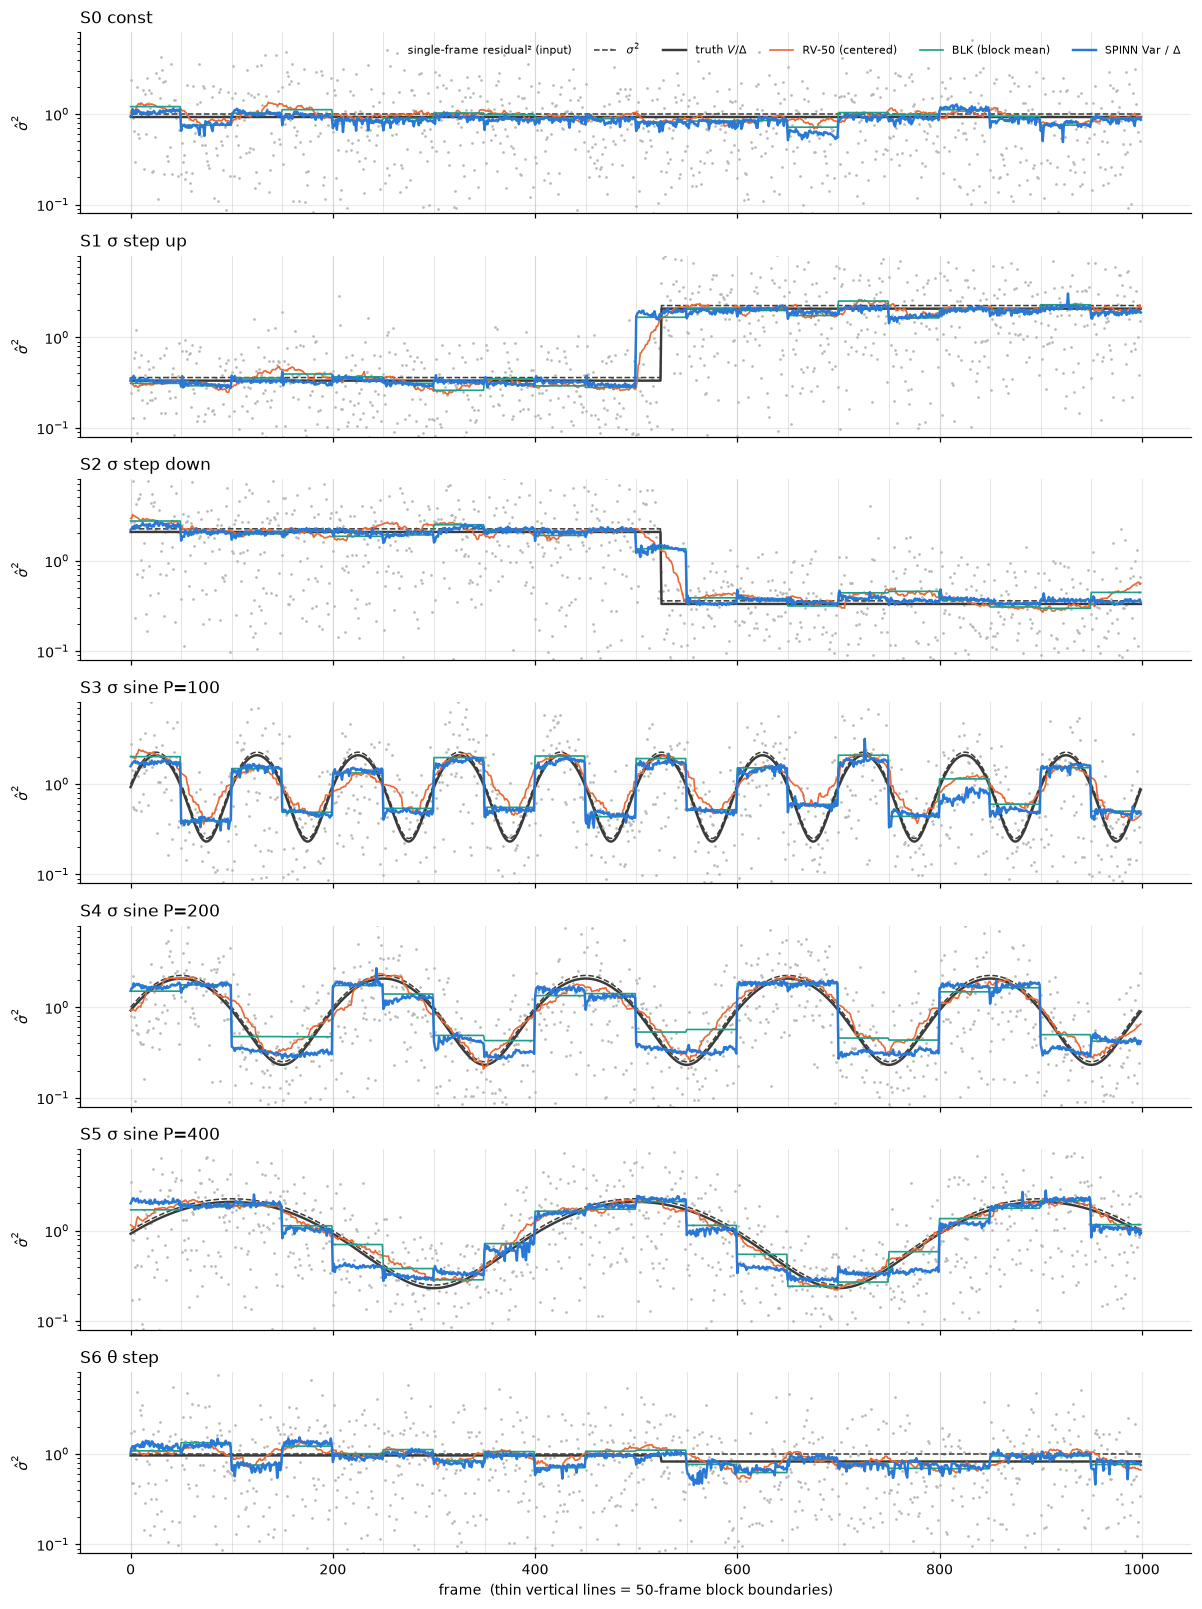

In [10]:
names = list(TEST)
fig, axes = plt.subplots(len(names), 1, figsize=(11, 2.1 * len(names)), sharex=True)
n_ax = np.arange(T_LEN)
for ax, k in zip(axes, names):
    i = 0
    ax.plot(n_ax, U[k][i] / DT, '.', color='#b8b8b4', ms=1.5, label='single-frame residual² (input)')
    ax.plot(n_ax, TEST[k]['sig2'], color=C_TRUE, ls='--', lw=1, label=r'$\sigma^2$')
    ax.plot(n_ax, TEST[k]['V'] / DT, color=C_TRUE, lw=1.6, label=r'truth $V/\Delta$')
    ax.plot(n_ax, EST[k]['RV-50'][i] / DT, color=C_RV, lw=1.1, label='RV-50 (centered)')
    ax.plot(n_ax, EST[k]['BLK'][i] / DT, color=C_BLK, lw=1.1, label='BLK (block mean)')
    ax.plot(n_ax, EST[k]['SPINN Var'][i] / DT, color=C_SPINN, lw=1.6, label='SPINN Var / Δ')
    for b in range(0, T_LEN, BLOCK):
        ax.axvline(b, color='#dddddb', lw=0.5, zorder=0)
    ax.set_yscale('log'); ax.set_ylim(0.08, 8); ax.set_ylabel(r'$\hat\sigma^2$')
    ax.set_title(k, loc='left')
axes[0].legend(ncol=6, loc='upper right', fontsize=7.5)
axes[-1].set_xlabel('frame  (thin vertical lines = 50-frame block boundaries)')
fig.tight_layout(); plt.show()

### 6.2 校准与逐帧误差（全部 24 条轨迹 × 全部帧）

对每一帧计算对数误差 $e_n=\ln(\hat V_n/V_n)$，汇总：

- **偏差** $=\exp(\mathrm{median}\,e)$：1 表示无系统偏差；
- **逐帧 RMS** $=\sqrt{\overline{e^2}}$：约等于逐帧相对误差（对数尺度）；
- **中位相对误差** $=\mathrm{median}\,|\hat V/V-1|$；
- **等效窗口** $W_{\rm eq}=1/\mathrm{Var}(e)$：若把误差看作纯噪声，它相当于用多少帧（两维合并）做平均。仅在 S0（$\sigma$ 恒定）上有严格意义；
- **$\mathbb E[u]/V$**：扩散网络输入（主网络残差平方）的均值与真值之比，检查主网络的一步预测是否把漂移误差混入了残差。

In [11]:
def err_table(keys=('SPINN Var', 'BLK', 'RV-25', 'RV-50', 'RV-100')):
    rows = []
    for k in names:
        V = np.broadcast_to(TEST[k]['V'], (N_EVAL, T_LEN))
        for m in keys:
            e = np.log(EST[k][m] / V)[:, VALID]
            e = e[np.isfinite(e)]
            rows.append(dict(scenario=k, method=m, bias=np.exp(np.median(e)), rms_log=np.sqrt(np.mean(e ** 2)),
                             med_rel=np.median(np.abs(np.exp(e) - 1)), W_eq=1 / np.var(e)))
        uu = U[k] / V
        rows.append(dict(scenario=k, method='E[u]/V', bias=np.nanmean(uu)))
    return pd.DataFrame(rows)

TAB = err_table()
piv = TAB[TAB.method != 'E[u]/V'].pivot(index='scenario', columns='method', values=['bias', 'rms_log', 'med_rel'])
display(piv.loc[names].round(3))
print('主网络残差平方均值 / 真值 V：')
print(TAB[TAB.method == 'E[u]/V'].set_index('scenario')['bias'].round(3).to_string())
s0 = TAB[(TAB.scenario == 'S0 const')].set_index('method')
print('\nS0 常数情景的等效平均窗口 W_eq（帧，x/y 两维合并）：')
print(s0['W_eq'].dropna().round(0).to_string())
print('理论：一个 50 帧块内 49 帧 × 2 维 → 1/W_eq 的下限对应 W_eq ≈ 49')

bias                                rms_log                \
method             BLK RV-100  RV-25  RV-50 SPINN Var     BLK RV-100  RV-25   
scenario                                                                      
S0 const         1.003  1.029  1.009  1.019     0.950   0.147  0.111  0.209   
S1 σ step up     1.010  1.038  1.025  1.034     0.992   0.262  0.230  0.228   
S2 σ step down   1.031  1.047  1.042  1.045     1.038   0.270  0.243  0.238   
S3 σ sine P=100  1.052  1.164  1.079  1.165     1.013   0.397  0.815  0.252   
S4 σ sine P=200  1.050  1.151  1.044  1.089     0.967   0.396  0.394  0.213   
S5 σ sine P=400  1.042  1.097  1.044  1.065     1.013   0.230  0.179  0.211   
S6 θ step        1.044  1.060  1.050  1.061     0.986   0.150  0.120  0.209   

                                 med_rel                                 
method           RV-50 SPINN Var     BLK RV-100  RV-25  RV-50 SPINN Var  
scenario                                                                 
S0 const         0.151     0.167   0.102  0.078  0.137  0.101     0.085  
S1 σ step up     0.203     0.240   0.110  0.084  0.140  0.106     0.060  
S2 σ step down   0.218     0.271   0.112  0.092  0.145  0.111     0.082  
S3 σ sine P=100  0.411     0.405   0.276  0.481  0.174  0.273     0.278  
S4 σ sine P=200  0.205     0.427   0.276  0.243  0.148  0.143     0.273  
S5 σ sine P=400  0.162     0.288   0.154  0.117  0.145  0.113     0.168  
S6 θ step        0.156     0.175   0.112  0.085  0.149  0.113     0.091

主网络残差平方均值 / 真值 V：
scenario
S0 const           1.013
S1 σ step up       1.018
S2 σ step down     1.036
S3 σ sine P=100    1.031
S4 σ sine P=200    1.026
S5 σ sine P=400    1.037
S6 θ step          1.041

S0 常数情景的等效平均窗口 W_eq（帧，x/y 两维合并）：
method
SPINN Var    41.0
BLK          46.0
RV-25        23.0
RV-50        45.0
RV-100       86.0
理论：一个 50 帧块内 49 帧 × 2 维 → 1/W_eq 的下限对应 W_eq ≈ 49


### 6.3 阶跃响应（S1、S2）

对 24 条轨迹逐帧取对数平均，并标准化为 $y_n=\frac{\ln\hat V_n-\ln V_{\text{前}}}{\ln V_{\text{后}}-\ln V_{\text{前}}}$（0 = 阶跃前真值，1 = 阶跃后真值）。报告：

- **平台比值**：阶跃后（第 600–999 帧）与阶跃前（第 0–449 帧）的 $\hat V$ 中位数之比，真值为 6.25（S1）或 0.16（S2）；
- **10%–90% 上升时间**（帧）与**半程时间**（$y$ 越过 0.5 的帧相对阶跃时刻的偏移，负值表示提前）。

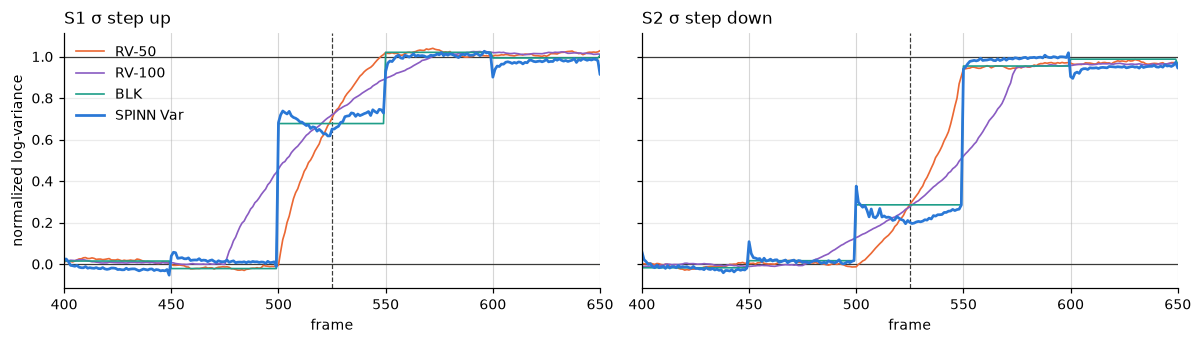

ratio  true_ratio  t10  t50  t90  rise_10_90
scenario       method                                                 
S1 σ step up   RV-50       6.54        6.25  -23  -10   13          36
               RV-100      6.50        6.25  -46  -21   27          73
               BLK         6.52        6.25  -25  -25   25          50
               SPINN Var   6.27        6.25  -25  -25   25          50
S2 σ step down RV-50       0.16        0.16  -13   12   24          37
               RV-100      0.16        0.16  -30   24   48          78
               BLK         0.16        0.16  -25   25   25          50
               SPINN Var   0.16        0.16  -75   25   25         100

In [12]:
def step_metrics(k, m):
    V = TEST[k]['V']; lv0, lv1 = np.log(V[0]), np.log(V[-2])
    E = EST[k][m]
    ly = np.nanmean(np.log(E), axis=0)
    y = (ly - lv0) / (lv1 - lv0)
    pre = np.nanmedian(E[:, :450]); post = np.nanmedian(E[:, 600:999])
    win = np.arange(STEP_N - 150, STEP_N + 150)
    yy = y[win]
    def cross(level):
        idx = np.where(yy >= level)[0]
        return win[idx[0]] - STEP_N if len(idx) else np.nan
    return y, dict(ratio=post / pre, true_ratio=V[-2] / V[0], t10=cross(0.1), t50=cross(0.5), t90=cross(0.9),
                   rise_10_90=cross(0.9) - cross(0.1))

rows, fig, axes = [], *plt.subplots(1, 2, figsize=(11, 3.2), sharey=True)
for ax, k in zip(axes, ['S1 σ step up', 'S2 σ step down']):
    ax.axhline(0, color=C_TRUE, lw=0.8); ax.axhline(1, color=C_TRUE, lw=0.8)
    ax.axvline(STEP_N, color=C_TRUE, ls='--', lw=0.8)
    for m, c in [('RV-50', C_RV), ('RV-100', C_RV2), ('BLK', C_BLK), ('SPINN Var', C_SPINN)]:
        y, d = step_metrics(k, m)
        ax.plot(np.arange(T_LEN), y, color=c, lw=1.8 if m == 'SPINN Var' else 1.1, label=m)
        rows.append(dict(scenario=k, method=m, **d))
    for b in range(400, 700, BLOCK):
        ax.axvline(b, color='#dddddb', lw=0.5, zorder=0)
    ax.set_xlim(STEP_N - 125, STEP_N + 125); ax.set_title(k, loc='left'); ax.set_xlabel('frame')
axes[0].set_ylabel('normalized log-variance'); axes[0].legend(loc='upper left')
fig.tight_layout(); plt.show()
display(pd.DataFrame(rows).set_index(['scenario', 'method']).round(2))

### 6.4 频率响应（S3–S5：$\sigma$ 正弦变化）

对每条轨迹，把 $\ln\hat V_n$ 在已知频率上回归到 $[1,\sin\omega n,\cos\omega n]$，得到振幅与相位；对真值 $\ln V_n$ 做同样的回归。

- **增益** = 估计振幅 / 真值振幅（1 = 完全跟上，0 = 完全抹平）；
- **滞后**（帧）= 估计相对真值的相位延迟；
- **单轨迹相关** = 每条轨迹上 $\ln\hat V_n$ 与 $\ln V_n$ 的相关系数（24 条取中位数）。

gain                              lag_frames                     \
method   BLK RV-100 RV-25 RV-50 SPINN Var        BLK RV-100 RV-25 RV-50   
period                                                                    
100     0.75   0.03  0.87  0.59      0.72      -0.53   2.74  0.47  1.24   
200     0.76   0.60  0.95  0.87      0.89       0.66   1.38  0.13  0.68   
400     0.93   0.87  0.98  0.96      0.93      -0.20  -0.27 -0.89 -0.36   

                  corr                               
method SPINN Var   BLK RV-100 RV-25 RV-50 SPINN Var  
period                                               
100         0.31  0.87   0.13  0.95  0.93      0.86  
200         0.32  0.86   0.94  0.97  0.98      0.85  
400        -1.64  0.96   0.98  0.96  0.98      0.93

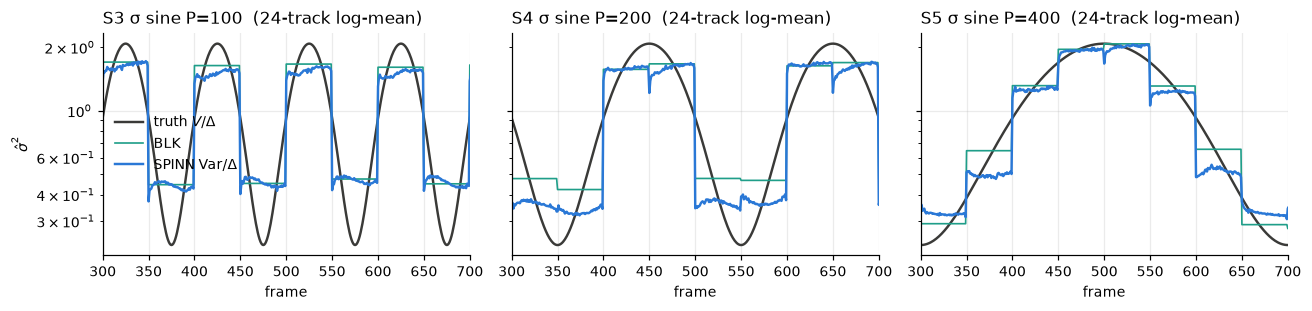

In [13]:
def harmonic(y, P):
    n = np.arange(T_LEN); ok = np.isfinite(y) & VALID
    A = np.c_[np.ones(ok.sum()), np.sin(2 * np.pi * n[ok] / P), np.cos(2 * np.pi * n[ok] / P)]
    c = np.linalg.lstsq(A, y[ok], rcond=None)[0]
    return np.hypot(c[1], c[2]), np.arctan2(c[2], c[1])

rows = []
for k, P in PERIOD.items():
    amp0, ph0 = harmonic(np.log(TEST[k]['V']), P)
    for m in ['SPINN Var', 'BLK', 'RV-25', 'RV-50', 'RV-100']:
        g, lag, cc = [], [], []
        for i in range(N_EVAL):
            ly = np.log(EST[k][m][i]); a, ph = harmonic(ly, P)
            g.append(a / amp0); lag.append(((ph0 - ph + np.pi) % (2 * np.pi) - np.pi) / (2 * np.pi) * P)
            ok = np.isfinite(ly) & VALID
            cc.append(np.corrcoef(ly[ok], np.log(TEST[k]['V'])[ok])[0, 1])
        rows.append(dict(period=P, method=m, gain=np.median(g), lag_frames=np.median(lag), corr=np.median(cc)))
FR = pd.DataFrame(rows)
display(FR.pivot(index='period', columns='method', values=['gain', 'lag_frames', 'corr']).round(2))

fig, axes = plt.subplots(1, 3, figsize=(12, 2.9), sharey=True)
for ax, (k, P) in zip(axes, PERIOD.items()):
    n = np.arange(T_LEN)
    ax.plot(n, TEST[k]['V'] / DT, color=C_TRUE, lw=1.6, label=r'truth $V/\Delta$')
    ax.plot(n, np.exp(np.nanmean(np.log(EST[k]['BLK']), 0)) / DT, color=C_BLK, lw=1.1, label='BLK')
    ax.plot(n, np.exp(np.nanmean(np.log(EST[k]['SPINN Var']), 0)) / DT, color=C_SPINN, lw=1.6, label='SPINN Var/Δ')
    ax.set_xlim(300, 700); ax.set_yscale('log'); ax.set_title(f'{k}  (24-track log-mean)', loc='left')
    ax.set_xlabel('frame')
axes[0].set_ylabel(r'$\hat\sigma^2$'); axes[0].legend()
fig.tight_layout(); plt.show()

### 6.5 物理层：$\theta$ 变化会不会被读成 $\sigma^2$ 变化？（S6）

S6 中 $\sigma\equiv1$，只有 $\theta$ 从 2 跳到 10。真值：

- $\sigma^2$ 比值 = 1；
- 单步方差 $V$ 比值 $=g(10\Delta)/g(2\Delta)=0.824/0.961\approx0.858$。

若直接用 $\hat\sigma^2=\mathrm{Var}/\Delta$，则会看到一个虚假的 $\sigma^2$ 下降。下表同时列出 $g(\theta\Delta)$ 随 $\theta\Delta$ 的变化，即 “$\mathrm{Var}/\Delta$ 作为 $\sigma^2$ 估计”的**固有偏差**。

In [14]:
k = 'S6 θ step'
rows = []
for m in ['SPINN Var', 'BLK', 'RV-50', 'RV-100']:
    E = EST[k][m]
    rows.append(dict(method=m, post_over_pre=np.nanmedian(E[:, 600:999]) / np.nanmedian(E[:, :450]),
                     pre_sig2_hat=np.nanmedian(E[:, :450]) / DT, post_sig2_hat=np.nanmedian(E[:, 600:999]) / DT))
V = TEST[k]['V']
rows.append(dict(method='truth V', post_over_pre=V[-2] / V[0], pre_sig2_hat=V[0] / DT, post_sig2_hat=V[-2] / DT))
rows.append(dict(method='truth σ²', post_over_pre=1.0, pre_sig2_hat=1.0, post_sig2_hat=1.0))
display(pd.DataFrame(rows).set_index('method').round(3))

g = lambda x: (1 - np.exp(-2 * x)) / (2 * x)
thD = np.array([0.01, 0.02, 0.05, 0.08, 0.1, 0.2, 0.3, 0.5, 1.0])
display(pd.DataFrame({'θΔ': thD, 'g(θΔ)=V/(σ²Δ)': g(thD).round(3),
                      'Var/Δ 低估 σ² 的比例': (1 - g(thD)).round(3)}).set_index('θΔ').T)

,post_over_pre,pre_sig2_hat,post_sig2_hat
method,,,
SPINN Var,0.930,0.907,0.843
BLK,0.881,0.980,0.864
RV-50,0.920,0.980,0.901
RV-100,0.917,0.981,0.900
truth V,0.858,0.961,0.824
truth σ²,1.000,1.000,1.000


θΔ,0.01,0.02,0.05,0.08,0.10,0.20,0.30,0.50,1.00
g(θΔ)=V/(σ²Δ),0.99,0.98,0.952,0.924,0.906,0.824,0.752,0.632,0.432
Var/Δ 低估 σ² 的比例,0.01,0.02,0.048,0.076,0.094,0.176,0.248,0.368,0.568


### 6.6 偏差-噪声权衡：SPINN 相当于多宽的平均窗口？

对 `RV-W` 扫描窗口宽度 $W$，画出逐帧对数 RMS 误差随 $W$ 的变化（小 $W$ 噪声大，大 $W$ 跟不上变化）。水平线是 SPINN `Var` 和 `BLK` 的误差。虚线是纯噪声理论值 $1/\sqrt{W}$（$2W$ 个 $\chi^2_1$ 样本平均的对数标准差）。

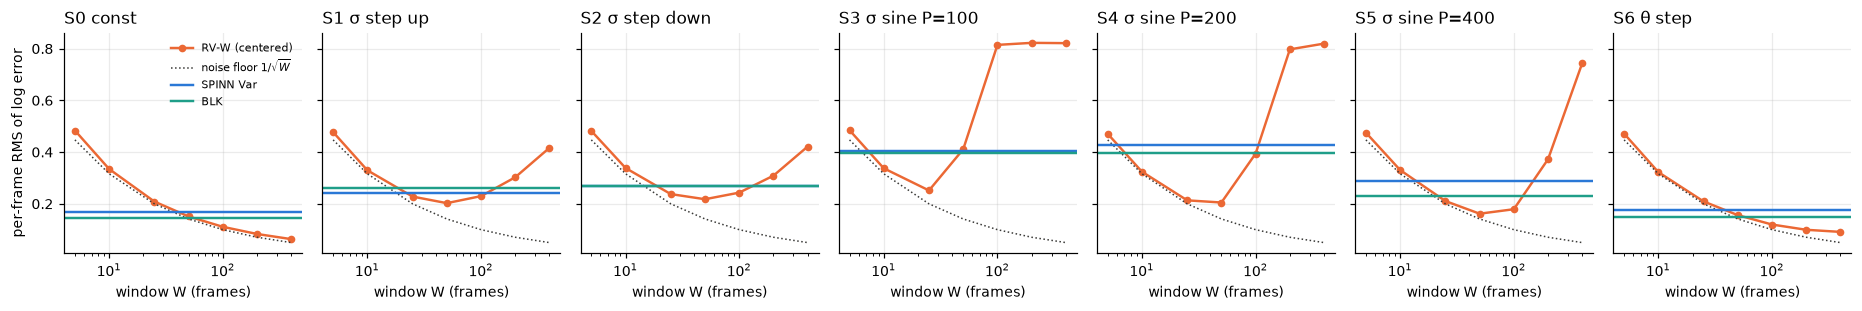

In [15]:
Ws = [5, 10, 25, 50, 100, 200, 400]
fig, axes = plt.subplots(1, len(names), figsize=(17, 2.9), sharey=True)
for ax, k in zip(axes, names):
    X = TEST[k]['X']; V = TEST[k]['V']
    dx2 = np.full(X.shape[:2], np.nan); dx2[:, :-1] = (np.diff(X, axis=1) ** 2).mean(-1)
    r = []
    for W in Ws:
        e = np.log(rolling_mean(dx2, W) / V)[:, VALID]; r.append(np.sqrt(np.nanmean(e ** 2)))
    ax.plot(Ws, r, 'o-', color=C_RV, ms=4, label='RV-W (centered)')
    ax.plot(Ws, 1 / np.sqrt(Ws), ':', color=C_TRUE, lw=1, label=r'noise floor $1/\sqrt{W}$')
    for m, c in [('SPINN Var', C_SPINN), ('BLK', C_BLK)]:
        e = np.log(EST[k][m] / V)[:, VALID]
        ax.axhline(np.sqrt(np.nanmean(e ** 2)), color=c, lw=1.6, label=m)
    ax.set_xscale('log'); ax.set_title(k, loc='left'); ax.set_xlabel('window W (frames)')
axes[0].set_ylabel('per-frame RMS of log error'); axes[0].legend(fontsize=7)
fig.tight_layout(); plt.show()

### 6.7 自洽性检查：标准化残差

若 `Var` 正确，$z_n=r_n/\sqrt{\mathrm{Var}_n}$（$r_n$ 为主网络一步残差）应为 $\mathcal N(0,1)$。对 S1 分别在阶跃前、阶跃所在块、阶跃后统计 $\mathrm{std}(z)$。**注意**：$z$ 的检验对“块内平均”这类估计量天然成立，所以它只能说明二阶矩自洽，不能证明逐帧准确。

In [16]:
rows = []
for k in names:
    r = RES[k]; z = r['resid'] / np.sqrt(r['s1'])
    z[r['last']] = np.nan
    parts = {'all': slice(0, T_LEN)}
    if 'step' in k:
        parts.update({'pre (0-499)': slice(0, 500), 'step block (500-549)': slice(500, 550), 'post (550-999)': slice(550, T_LEN)})
    for p, sl in parts.items():
        zz = z[:, sl].ravel(); zz = zz[np.isfinite(zz)]
        rows.append(dict(scenario=k, part=p, std_z=zz.std(), kurtosis=((zz - zz.mean()) ** 4).mean() / zz.var() ** 2))
display(pd.DataFrame(rows).set_index(['scenario', 'part']).round(3))

std_z  kurtosis
scenario        part                                 
S0 const        all                   1.046     3.006
S1 σ step up    all                   1.010     2.966
                pre (0-499)           0.994     2.937
                step block (500-549)  0.971     4.071
                post (550-999)        1.031     2.887
S2 σ step down  all                   1.003     2.969
                pre (0-499)           1.018     2.882
                step block (500-549)  0.962     4.056
                post (550-999)        0.991     2.962
S3 σ sine P=100 all                   1.026     3.244
S4 σ sine P=200 all                   1.074     3.200
S5 σ sine P=400 all                   1.044     3.077
S6 θ step       all                   1.045     3.023
                pre (0-499)           1.047     2.997
                step block (500-549)  1.053     2.955
                post (550-999)        1.041     3.059

### 6.8 尺度等变性

SPINN 对每条轨迹按步长均方根归一化，再乘回 $s_d^2$，所以把整条轨迹放大 $c$ 倍，`Var` 应恰好放大 $c^2$ 倍。这意味着**绝对水平**完全由归一化决定，网络只负责轨迹内部的**相对形状**。

In [17]:
k = 'S1 σ step up'
for c in [0.1, 3.0]:
    r2 = infer(TEST[k]['X'][:6] * c)
    ratio = r2['s1'] / RES[k]['s1'][:6]
    print(f'轨迹 ×{c}: Var 比值 范围 [{np.nanmin(ratio):.6f}, {np.nanmax(ratio):.6f}]，理论 {c**2}')

轨迹 ×0.1: Var 比值 范围 [0.009884, 0.010065]，理论 0.010000000000000002


轨迹 ×3.0: Var 比值 范围 [8.999470, 9.000943]，理论 9.0



## 7. 结论（`SEED=0`、`QUICK=True`、4 核 CPU）

### 7.1 `Var` 能否反映 $\sigma^2$ 的变化？——**水平上能，时间分辨率上不能到单帧**

**能做到的：**

- **几乎无偏**：各情景 `Var` 对真值 $V_n$ 的中位偏差为 −5%～+4%（S0 为 0.95）；主网络残差平方的均值只比真值高 1%–4%，说明漂移/扩散的二阶矩分解是对的。
- **阶跃幅度准确**：S1 阶跃后/前的比值为 6.27（真值 6.25），S2 为 0.16（真值 0.16）。
- **自洽且尺度等变**：标准化残差的 $\mathrm{std}(z)$ 为 0.96–1.07；把轨迹缩放 $c$ 倍，`Var` 恰好缩放 $c^2$ 倍。所以绝对水平由归一化保证，网络只负责轨迹内部的相对形状。
- **慢变化跟得上**：$\sigma$ 以 400 帧为周期变化时，增益为 0.93，单轨迹相关系数为 0.93。

**做不到的，而且原因是结构性的：**

- **`Var` 是按 50 帧块分段的平均值，不是逐帧估计。** §4 证实，由于 `transformToMemmap` 中 `tags_s == 'reverse'` 永远不成立，扩散网络的编码头只是本块残差的镜像。所以每一帧的 `Var` **只用到所在 50 帧块内的 49 个残差**，块与块之间不共享信息。§6.1 的曲线在块内几乎是常数，并与块平均 `BLK` 基本重合。
- **逐帧精度等价于约 40 帧的平均**：S0 的等效窗口 $W_{\rm eq}\approx41$ 帧（BLK 为 46，RV-50 为 45）。逐帧对数误差 RMS 为 0.17，还略差于简单的块平均（0.15）。也就是说，**扩散网络没有带来块平均以外的额外信息**。
- **时间分辨率 = 一个块**：阶跃发生在块中间时，整个块输出一个中间值。上升时间固定为 50 帧，而且跳变对齐的是块边界（第 500/550 帧），不是真实阶跃时刻（第 525 帧）。在 $\sigma$ 以 100 帧为周期振荡时，增益为 0.72（RV-25 为 0.87），单轨迹相关系数为 0.86（RV-50 为 0.93）。在所有 $\sigma$ 时变的情景中，SPINN 的逐帧误差都高于最优窗口的朴素滑动估计（§6.6）。

### 7.2 物理层：`Var/Δ` ≠ $\sigma^2$，差一个依赖 $\theta$ 的因子

$\mathrm{Var}/\Delta=\sigma^2\,g(\theta\Delta)$，其中 $g(x)=(1-e^{-2x})/(2x)$。

- 在 S6 中 $\sigma$ 恒定，$\theta$ 从 2 跳到 10。用 `Var/Δ` 读出的 $\hat\sigma^2$ 从 0.91 降到 0.84，出现了**虚假的 7% 下降**（真实单步方差比值为 0.86）。
- $\theta\Delta\le0.05$ 时，偏差 $\le5\%$，可以忽略；$\theta\Delta=0.2$ 时偏差为 18%，$\theta\Delta=0.5$ 时为 37%。这时必须用 $\theta$ 校正，而 SPINN 漂移项给出的 $\theta$ 本身不可靠（见 `SPINN_OU_demo.ipynb` 第 8.4、10 节）。

### 7.3 对你的两个目标的回答

| 目标 | 能否直接用默认 SPINN 的结果 | 说明 |
|---|---|---|
| **单轨迹 $\sigma^2_t$** | **有条件可以** | ① $\sigma$ 的变化要慢于约 100–200 帧；② 实际分辨率是 50 帧块，不是单帧；③ $\theta\Delta$ 较大时要除以 $g(\theta\Delta)$。精度与 50 帧滑动实现方差相当，并不更好。 |
| **单轨迹 $\sigma^2_t/\theta_t$** | **不能只靠 `Var`** | `Var` 几乎不含 $\theta$ 的信息（只有 $g(\theta\Delta)$ 这一弱依赖）。$\sigma^2/\theta = 2\,\mathrm{Var}_{\rm stat}(X)$ 需要位置的平稳方差或自相关 $e^{-\theta\Delta}$，而默认流程的扩散网络只看残差。 |

### 7.4 对设计新 head / 自监督损失的启示

1. **“单帧”的上限来自信息量，不来自网络。** 一帧残差平方的相对标准差约 141%（$\chi^2_1$），用 $W$ 帧（两维）合并后约为 $1/\sqrt W$。任何 head 都只能决定**怎样自适应地合并相邻帧**，而不能凭空得到单帧精度。所以设计的目标应当是：平稳段合并尽量多的帧，变化点处合并尽量少的帧。现有流程被块结构卡死在固定 50 帧。
2. **打破块隔离**：让方差 head 的上下文跨越块边界（使用真正的反向残差或重叠滑窗），否则无论 head 怎么设计，分辨率和精度都停在一个块上。
3. **用恰当评分规则直接训练方差 head**：在主网络上加一个 $\log V_t$ 输出，用高斯 NLL $\tfrac12[\,r_t^2/V_t+\log V_t\,]$ 训练。它的最优解就是条件方差，比现在“对残差平方再做一次平滑回归”更直接，也不需要第二个网络。
4. **针对 OU 的参数化 head**：输出 $(\phi_t=e^{-\theta_t\Delta},\,V_t)$，并用精确转移似然 $x_{t+1}\sim\mathcal N(m_t+\phi_t(x_t-m_t),\,V_t)$ 做自监督训练，其中 $m_t$ 为局部平衡位置。这样可以直接换算
   $$\sigma_t^2=\frac{2\theta_t V_t}{1-\phi_t^2},\qquad \frac{\sigma_t^2}{\theta_t}=\frac{2V_t}{1-\phi_t^2}=2\,\mathrm{Var}_{\rm stat}.$$
   其中 $\sigma^2/\theta$ 等价于位置的平稳方差，可以再加一个对局部位置方差的约束来稳定 $\phi_t$，因为单独从漂移中读 $\phi_t$ 信噪比很低。再对参数时间序列加平滑 / TV 正则，就能实现上面第 1 点的“自适应合并”。
